# Deep RL for Energy-Efficient Cloud Scheduling (Master Notebook)
## Reference Framework: Multi-Objective Reinforcement Learning for Cloud Task Scheduling

### Technical Specifications:
* **Simulation Core:** Fully compliant `gymnasium.Env` architecture modeling a heterogeneous multi-server cloud cluster under stochastic task arrivals.
* **Agent Infrastructure:** Stable-Baselines3 (SB3) framework training both a Value-Based (DQN) agent and a Policy-Gradient Actor-Critic (PPO) agent under a scalarized throughput/latency/energy reward.
* **Fidelity Level:** Direct empirical benchmarking against four deterministic/stochastic heuristic control baselines (Round Robin, SJF, Greedy Min-Min, Random) across variable workload intensities.

### 8-Server Extension: Action-Space Scaling Study
Re-instantiates `CloudSchedulingEnv` with `n_servers = 8` (double the original 4-server configuration) to test whether the trained agents and static heuristics generalise to a larger scheduling action space.


# Setup


## Section 1: Framework Dependencies & Installation
Installs the Stable-Baselines3 reinforcement learning library required to construct and train the DQN and PPO scheduling agents.


In [1]:
# Install required Reinforcement Learning library
!pip install stable_baselines3


## Section 2: Environment Setup & Framework Dependencies
Initializes core numerical libraries, reinforcement learning frameworks, visualization backends, and the structured output workspace.


In [2]:
# Core Libraries
import numpy as np
import pandas as pd

# Reinforcement Learning Frameworks
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN, PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor

# Visualization Setup
import matplotlib
matplotlib.use("Agg")  # Force matplotlib to use non-interactive background rendering for server stability
import matplotlib.pyplot as plt

# System & Utilities
import os, tempfile
import warnings

# Suppress underlying low-level deprecation and runtime warnings
warnings.filterwarnings("ignore")

# Workspace Initialization
# Create structured directories for trained models, evaluation logs, figures, and TensorBoard telemetry
for d in ["models", "results", "results/tables", "results/figures", "tb_logs"]:
    os.makedirs(d, exist_ok=True)


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Section 3: Global Configuration & Hyperparameters
Defines the runtime execution profile (`demo` vs. `full`), reinforcement learning training budgets, and an estimated wall-clock runtime diagnostic for the complete pipeline.


In [3]:
# Execution Toggle
# "demo" for rapid testing/debugging; "full" for complete benchmarking and production runs
MODE = "full"
SEED = 42

# Hyperparameter Sets by Mode
if MODE == "demo":
    TRAIN_TIMESTEPS  = 10_000
    SENS_TIMESTEPS   = 5_000
    EVAL_EPISODES    = 3
    EPISODE_LENGTH   = 100
    ARRIVAL_RATES    = [0.0, 1.0, 2.0]
    SENS_EPISODES    = 3
else:
    TRAIN_TIMESTEPS  = 200_000
    SENS_TIMESTEPS   = 30_000
    EVAL_EPISODES    = 20
    EPISODE_LENGTH   = 200
    ARRIVAL_RATES    = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]
    SENS_EPISODES    = 10

# Environment & Logging Parameters
N_SERVERS        = 8   # Scaled action-space size for this experiment (baseline notebook used 4)
ARRIVAL_RATE_TR  = 1.0
SENS_ARRIVAL     = 1.0
RESULTS_DIR      = "results"
MODELS_DIR       = "models"
LOG_DIR          = "tb_logs"

# Runtime Complexity Estimation
spd = 10_000  # Assumed processing speed: steps per second (hardware-dependent benchmark)

# Calculate expected runtime for each phase
t_train = (TRAIN_TIMESTEPS * 2) / spd                                       # 2 distinct RL agents trained
t_sens  = (SENS_TIMESTEPS * 10) / spd                                       # Fine-tuning over 10 distinct configurations
t_eval  = (EVAL_EPISODES * len(ARRIVAL_RATES) * 6 * EPISODE_LENGTH) / spd   # Combinatorial policy evaluation matrix
total   = t_train + t_sens + t_eval

# Status & Diagnostic Report
print(f"Mode: {MODE}")
print(f"  Servers (N)      : {N_SERVERS}")
print(f"  Train timesteps  : {TRAIN_TIMESTEPS:,}")
print(f"  Sensitivity steps: {SENS_TIMESTEPS:,} × 10 configs (fine-tune)")
print(f"  Eval episodes    : {EVAL_EPISODES} × {len(ARRIVAL_RATES)} rates × 6 policies")
print(f"\nEstimated runtime on CPU:")
print(f"  Training   : {t_train/60:.1f} min")
print(f"  Sensitivity: {t_sens/60:.1f} min")
print(f"  Evaluation : {t_eval/60:.1f} min")
print(f"  ──────────────────────")
print(f"  Total         : {total/60:.1f} min  (~{total/3600:.2f} hrs)")


Mode: full
  Servers (N)      : 8
  Train timesteps  : 200,000
  Sensitivity steps: 30,000 × 10 configs (fine-tune)
  Eval episodes    : 20 × 6 rates × 6 policies

Estimated runtime on CPU:
  Training   : 0.7 min
  Sensitivity: 0.5 min
  Evaluation : 0.2 min
  ──────────────────────
  Total         : 1.4 min  (~0.02 hrs)


## Section 4: Cloud Scheduling Environment (`CloudSchedulingEnv`)
Encapsulates the discrete Markov Decision Process (MDP) for sequential online task scheduling into a standard, unified `gymnasium.Env` interface, instantiated at `n_servers = 8` to test scaling of the state/action spaces beyond the original 4-server configuration.




In [4]:
# Environmental Constants
STEP_DURATION_MS = 1000.0          # Simulation step temporal resolution


class CloudSchedulingEnv(gym.Env):
    """
    Custom Gymnasium Environment for multi-objective, energy-aware cloud task scheduling.

    MDP Formulation Mappings:
    - State Space   : Flattened per-server utilization/queue descriptors plus current-task
                       and global-context features, normalized to [0, 1] (dimension 5·N + 6)
    - Action Space  : Discrete choice of target server for the incoming task (A_t ∈ {0, ..., N-1})
    - Reward System : Scalarized combination of throughput, latency, and energy penalty terms
    """
    metadata = {"render_modes": ["human"]}

    def __init__(
        self,
        n_servers: int = 8,
        cpu_capacity: float = 100.0,
        ram_capacity: float = 100.0,
        p_idle: float = 100.0,
        p_max: float = 250.0,
        max_queue_len: int = 10,
        exec_length_range: tuple = (1, 10),
        cpu_demand_range: tuple = (5.0, 30.0),
        mem_demand_range: tuple = (5.0, 30.0),
        n_priority_levels: int = 3,
        arrival_rate: float = 0.5,
        max_arrival_rate: float = 5.0,
        episode_length: int = 200,
        w1: float = 0.5,
        w2: float = 0.3,
        w3: float = 0.2,
        reward_scale: float = 10.0,  # Scaled for RL training stability
        seed: int | None = None,
    ):
        super().__init__()

        # Core Resource Capacities
        self.n_servers        = n_servers
        self.cpu_capacity     = cpu_capacity
        self.ram_capacity     = ram_capacity

        # Power Consumption Specs (Linear Power Model)
        self.p_idle           = p_idle
        self.p_max            = p_max

        # Task Characteristics & Schedulers
        self.max_queue_len    = max_queue_len
        self.exec_length_range = exec_length_range
        self.cpu_demand_range = cpu_demand_range
        self.mem_demand_range = mem_demand_range
        self.n_priority_levels = n_priority_levels
        self.arrival_rate     = arrival_rate
        self.max_arrival_rate = max_arrival_rate
        self.episode_length   = episode_length

        # Multi-Objective Reward Weights & Scaling
        self.w1, self.w2, self.w3 = w1, w2, w3
        self.reward_scale     = reward_scale

        # Boundary Normalization Constants
        self._sec_per_step = STEP_DURATION_MS / 1000.0
        self.T_min = 0.0
        self.T_max = (n_servers + 2) / self._sec_per_step

        self.L_min = 0.0
        self.L_max = max_queue_len * exec_length_range[1] * STEP_DURATION_MS

        self.E_min = n_servers * p_idle
        self.E_max = n_servers * p_max

        self._idle_norm_cap = max_queue_len * exec_length_range[1]

        # RL Action & Observation Spaces
        self.action_space = spaces.Discrete(n_servers)  # Action = Select target server ID
        obs_dim = 5 * n_servers + 6                      # Vectorized state descriptor space
        self.observation_space = spaces.Box(0.0, 1.0, shape=(obs_dim,), dtype=np.float32)

        # Internal State Trackers
        self._rng = np.random.default_rng(seed)
        self.cpu_used = None
        self.ram_used = None
        self.queues   = None
        self.current_task = None
        self.step_count   = 0
        self.cum_throughput = 0
        self.cum_energy   = 0.0
        self.cum_latency  = 0.0

    def sample_task(self):
        """ Generates a randomized processing task bound by workload profiles """
        return {
            "cpu": self._rng.uniform(*self.cpu_demand_range),
            "mem": self._rng.uniform(*self.mem_demand_range),
            "exec_len": int(self._rng.integers(
                self.exec_length_range[0], self.exec_length_range[1] + 1)),
            "priority": int(self._rng.integers(1, self.n_priority_levels + 1)),
        }

    def reset(self, seed=None, options=None):
        """ Resets environment states to initial nominal conditions """
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)

        self.cpu_used = np.zeros(self.n_servers, dtype=np.float64)
        self.ram_used = np.zeros(self.n_servers, dtype=np.float64)

        self.queues   = [[] for _ in range(self.n_servers)]
        self.current_task = self.sample_task()
        self.step_count = 0
        self.cum_throughput = 0
        self.cum_energy = self.cum_latency = 0.0
        return self.get_obs(), {}

    def server_power(self, cpu_util: float) -> float:
        """ Computes server power consumption using a linear utilization model """
        return self.p_idle + (self.p_max - self.p_idle) * cpu_util

    def get_obs(self) -> np.ndarray:
        """ Constructs the flat, normalized observation vector for the agent """
        obs = []
        # Server-specific tracking states
        for i in range(self.n_servers):
            cu = float(np.clip(self.cpu_used[i] / self.cpu_capacity, 0, 1))
            ru = float(np.clip(self.ram_used[i] / self.ram_capacity, 0, 1))
            pn = cu
            qn = float(np.clip(len(self.queues[i]) / self.max_queue_len, 0, 1))

            idle_work = sum(e["exec_remaining"] for e in self.queues[i]
                             if e["status"] == "running")
            idn = float(np.clip(idle_work / self._idle_norm_cap, 0, 1))
            obs += [cu, ru, pn, qn, idn]

        # Global context and current task profiles (Min-Max Normalization to [0,1])
        t  = self.current_task
        cd = self.cpu_demand_range
        md = self.mem_demand_range
        el = self.exec_length_range
        obs += [
            (t["cpu"]      - cd[0]) / (cd[1] - cd[0]),
            (t["mem"]      - md[0]) / (md[1] - md[0]),
            (t["exec_len"] - el[0]) / (el[1] - el[0]),
            (t["priority"] - 1)     / (self.n_priority_levels - 1),
            float(np.mean(self.cpu_used / self.cpu_capacity)),
            float(np.clip(self.arrival_rate / self.max_arrival_rate, 0, 1)),
        ]
        return np.array(obs, dtype=np.float32)

    def step(self, action):
        """ Executes one operational scheduling step within the cluster """
        action = int(action)
        task = self.current_task

        # Phase 1: Task Distribution & Stochastic Background Arrivals
        self.queues[action].append({
            "exec_remaining": task["exec_len"], "cpu": task["cpu"],
            "mem": task["mem"], "status": "queued", "age_steps": 0,
        })

        # Model background load fluctuation using a Poisson distribution
        for _ in range(self._rng.poisson(self.arrival_rate)):
            et = self.sample_task()
            self.queues[int(self._rng.integers(0, self.n_servers))].append({
                "exec_remaining": et["exec_len"], "cpu": et["cpu"],
                "mem": et["mem"], "status": "queued", "age_steps": 0,
            })

        # Phase 2: Admission Control & Multi-Resource Allocation
        # Evaluate multi-resource capacity constraint bounds before execution
        for i in range(self.n_servers):
            for e in self.queues[i]:
                if e["status"] == "queued" and (
                    self.cpu_used[i] + e["cpu"] <= self.cpu_capacity and
                    self.ram_used[i] + e["mem"] <= self.ram_capacity
                ):
                    self.cpu_used[i] += e["cpu"]
                    self.ram_used[i] += e["mem"]
                    e["status"] = "running"

        # Phase 3: Resource Consumption Engine & Execution Processing
        completed = 0
        completed_ages_ms = []
        for i in range(self.n_servers):
            new_q = []
            for e in self.queues[i]:
                e["age_steps"] += 1
                if e["status"] == "running":
                    e["exec_remaining"] -= 1  # Process one unit of work per step
                    if e["exec_remaining"] <= 0:
                        self.cpu_used[i] -= e["cpu"]  # Deallocate resources upon termination
                        self.ram_used[i] -= e["mem"]
                        completed += 1
                        completed_ages_ms.append(e["age_steps"] * STEP_DURATION_MS)
                        continue
                new_q.append(e)
            self.queues[i] = new_q
            self.cpu_used[i] = max(0.0, self.cpu_used[i])
            self.ram_used[i] = max(0.0, self.ram_used[i])

        # Phase 4: Telemetry Calculations
        throughput_per_sec = completed / self._sec_per_step
        all_ages = [e["age_steps"] for q in self.queues for e in q]
        latency_ms = float(np.mean(all_ages) * STEP_DURATION_MS) if all_ages else 0.0
        total_power_watts = sum(
            self.server_power(np.clip(self.cpu_used[i] / self.cpu_capacity, 0, 1))
            for i in range(self.n_servers)
        )

        # Phase 5: Scalarized Objective Formulation
        # Map raw indicators to a standard unified [0,1] penalty/reward vector
        t_n = np.clip((throughput_per_sec - self.T_min) / (self.T_max - self.T_min), 0, 1)
        l_n = np.clip((latency_ms - self.L_min) / (self.L_max - self.L_min), 0, 1)
        e_n = np.clip((total_power_watts - self.E_min) / (self.E_max - self.E_min), 0, 1)
        reward = self.reward_scale * (self.w1 * t_n - self.w2 * l_n - self.w3 * e_n)

        # Phase 6: History Bookkeeping
        self.cum_throughput += completed
        self.cum_energy     += total_power_watts
        self.cum_latency    += latency_ms
        self.step_count     += 1
        self.current_task    = self.sample_task()

        info = {
            "throughput": throughput_per_sec,
            "latency": latency_ms,
            "energy": total_power_watts,
            "cum_throughput": self.cum_throughput,
            "cum_energy": self.cum_energy, "cum_latency": self.cum_latency,
        }
        return (self.get_obs(), float(reward),
                False, self.step_count >= self.episode_length, info)

    def get_server_stats(self):
        """ Extracts low-level per-server performance snapshots for diagnostics """
        stats = []
        for i in range(self.n_servers):
            stats.append({
                "cpu_used":  self.cpu_used[i],
                "ram_used":  self.ram_used[i],
                "free_cpu":  self.cpu_capacity - self.cpu_used[i],
                "free_ram":  self.ram_capacity - self.ram_used[i],
                "queue_len": len(self.queues[i]),
                "total_remaining_work": sum(e["exec_remaining"] for e in self.queues[i]),
            })
        return stats

    def render(self):
        """ Outputs a standard localized dashboard telemetry snapshot to CLI """
        s = self.get_server_stats()
        print("step={:4d} | ".format(self.step_count) +
              " | ".join(f"S{i}:cpu={x['cpu_used']:.0f} q={x['queue_len']}"
                         for i, x in enumerate(s)))


## Section 5: Environment Diagnostic & Integrity Verification
Runs a localized trace to validate state alignment, confirming the observation shape equals `5·N + 6` and that reward/info fields look sane.


In [5]:
# Initialize a localized trace for structural integrity validation
env = CloudSchedulingEnv(n_servers=N_SERVERS, seed=0)
obs, _ = env.reset()

# Assert vector dimensions match exactly the derived mathematical shape calculation (5*N + 6)
assert obs.shape == (5 * env.n_servers + 6,), "Critical Error: Unexpected observation vector shape!"
print("Observation shape:", obs.shape, " (expected", 5 * env.n_servers + 6, ")")

# Execution drift check: run a random walk for 10 steps to ensure runtime stability
for _ in range(10):
    a = env.action_space.sample()  # Uniform random sampling from defined action space
    obs, r, term, trunc, info = env.step(a)

# Metric Output Diagnostic
print("Sample info (throughput=tasks/sec | latency=ms | energy=Watts):")
for k in ["throughput", "latency", "energy"]:
    print(f"   {k}: {info[k]:.4f}")
print("Sample reward:", round(r, 5))

# Display active localized dashboard matrix via CLI
env.render()

# Garbage collection: clean up local verification references to avoid scoping issues
del env, obs, r, term, trunc, info, a


Observation shape: (46,)  (expected 46 )
Sample info (throughput=tasks/sec | latency=ms | energy=Watts):
   throughput: 1.0000
   latency: 4500.0000
   energy: 940.3162
Sample reward: 0.13114
step=  10 | S0:cpu=20 q=1 | S1:cpu=0 q=0 | S2:cpu=6 q=1 | S3:cpu=0 q=0 | S4:cpu=22 q=1 | S5:cpu=28 q=1 | S6:cpu=11 q=1 | S7:cpu=6 q=1


## Section 6: Traditional Heuristic Baselines (Control Benchmarks)
Implements four industry-standard non-learning control policies used across the stress-testing sweeps: **Round Robin**, **SJF** (shortest job first, queue-load variant), **Greedy Min-Min**, and **Random**.


In [6]:
class RoundRobinPolicy:
    """ Cyclic task distribution policy, independent of underlying server metrics """
    def __init__(self, n_servers, seed=None):
        self.n_servers = n_servers
        self._next = 0
    def reset(self):
        """ Resets the rotation pointer back to the primary server node """
        self._next = 0
    def select_action(self, env):
        """ Cycles sequentially through the available server index space """
        a = self._next
        self._next = (self._next + 1) % self.n_servers
        return a


class SJFPolicy:
    """ Queue-load mitigation variant selecting the resource with the least pending execution work """
    def __init__(self, n_servers, seed=None):
        self.n_servers = n_servers
    def reset(self):
        pass
    def select_action(self, env):
        stats = env.get_server_stats()
        loads = [s["total_remaining_work"] for s in stats]
        return int(np.argmin(loads))


class GreedyMinMinPolicy:
    """ Greedy optimization heuristic mapping incoming task profiles to minimize immediate completion bounds """
    def __init__(self, n_servers, seed=None):
        self.n_servers = n_servers
    def reset(self):
        pass
    def select_action(self, env):
        stats = env.get_server_stats()
        task = env.current_task
        completion_estimates = [
            s["total_remaining_work"] + task["exec_len"] for s in stats
        ]
        return int(np.argmin(completion_estimates))


class RandomPolicy:
    """ Stochastic baseline utilizing uniform random sampling across the discrete action space """

    def __init__(self, n_servers, seed=None):
        self.n_servers = n_servers
        self._rng = np.random.default_rng(seed)
    def reset(self):
        pass
    def select_action(self, env):
        return int(self._rng.integers(0, self.n_servers))


# Centralized Policy Registry Map
REGISTRY = {
    "RoundRobin": RoundRobinPolicy,
    "SJF": SJFPolicy,
    "GreedyMinMin": GreedyMinMinPolicy,
    "Random": RandomPolicy,
}


def make_heuristic(name, n_servers, seed=None):
    """ Factory function instantiating explicit deterministic/stochastic heuristics """
    if name not in REGISTRY:
        raise ValueError(f"Unknown heuristic '{name}'. Choices: {list(REGISTRY)}")
    return REGISTRY[name](n_servers, seed=seed)


In [7]:
# Heuristic Verification Loop (Smoke-Test Engine)
print("Heuristic smoke-test (50 steps, arrival_rate=0.5):")

for name in ["RoundRobin", "SJF", "GreedyMinMin", "Random"]:
    # Instantiate isolated environment and policy instance for each baseline
    te = CloudSchedulingEnv(n_servers=N_SERVERS, seed=1)
    te.reset()

    pol = make_heuristic(name, te.n_servers, seed=1)
    pol.reset()

    r_tot = 0.0

    # Run a short 50-step trajectory execution to assert data pipeline flow
    for _ in range(50):
        a = pol.select_action(te)
        _, r, _, _, info = te.step(a)
        r_tot += r

    # Output cumulative metrics to cross-verify basic numeric sanity
    print(f"  {name:<14}  total_reward={r_tot:7.3f}  "
          f"last_latency={info['latency']:.0f} ms  last_energy={info['energy']:.1f} W")

# Garbage collection: drop local tracking scopes to release process memory
del te, pol, r_tot, r, info, a


Heuristic smoke-test (50 steps, arrival_rate=0.5):
  RoundRobin      total_reward= 14.606  last_latency=4625 ms  last_energy=1006.5 W
  SJF             total_reward= 14.606  last_latency=4625 ms  last_energy=1006.5 W
  GreedyMinMin    total_reward= 14.606  last_latency=4625 ms  last_energy=1006.5 W
  Random          total_reward= 14.606  last_latency=4625 ms  last_energy=1006.5 W


## Section 7: Deep RL Agent Synthesis & Training (DQN & PPO)
Constructs the training pipeline helpers and factory functions for the Value-Based (DQN) and Policy-Gradient (PPO) agents, scaled to the 8-server action space via `net_arch=[256, 256]`, then executes the primary training runs under the configured execution profile.


In [8]:
# PART A: TRAINING PIPELINE HELPERS & INFERENCE CONFIGURATIONS

def make_env_fn(arrival_rate, episode_length, seed, w1=0.5, w2=0.3, w3=0.2,
                 reward_scale=10.0):
    """ Instantiates and wraps the custom cloud environment with the standard SB3 Monitor """
    def _init():
        return Monitor(CloudSchedulingEnv(
            n_servers=N_SERVERS, arrival_rate=arrival_rate,
            episode_length=episode_length,
            w1=w1, w2=w2, w3=w3, seed=seed,
            reward_scale=reward_scale,  # Amplify reward scalar bounds for gradient stability
        ))
    return _init


def clone_model(model, ModelClass, new_env):
    """ Deep-clones an active RL model via serialization to rebind it to a target environment """
    with tempfile.NamedTemporaryFile(suffix=".zip", delete=False) as f:
        tmp = f.name
    try:
        model.save(tmp)
        return ModelClass.load(tmp, env=new_env, device="cpu")
    finally:
        os.remove(tmp)


# PART B: DEEP RL AGENT TRAINING DEFINITIONS

def train_dqn(timesteps, arrival_rate=1.0, seed=42,
              w1=0.5, w2=0.3, w3=0.2, verbose=0,
              pretrained_model=None):
    """ Configures, initializes, and runs the training loop for the DQN agent """
    env = make_env_fn(arrival_rate, EPISODE_LENGTH, seed, w1, w2, w3)()

    if pretrained_model is not None:
        # Fine-tune phase: continue learning over pre-allocated structural parameters
        pretrained_model.learn(total_timesteps=timesteps, reset_num_timesteps=False)
        return pretrained_model

    # Build nominal Value-Based Deep Q-Network topology
    model = DQN(
        "MlpPolicy", env,
        learning_rate=5e-4,
        buffer_size=100_000,
        learning_starts=1_000,
        batch_size=128,
        gamma=0.99, train_freq=4,
        target_update_interval=1_000,
        exploration_fraction=0.30,
        exploration_final_eps=0.05,
        policy_kwargs=dict(net_arch=[256, 256]),
        verbose=verbose, tensorboard_log=LOG_DIR, seed=seed,
    )
    model.learn(total_timesteps=timesteps, tb_log_name="DQN")
    model.save(os.path.join(MODELS_DIR, "dqn_cloud_scheduler"))
    return model


def train_ppo(timesteps, arrival_rate=1.0, seed=42,
              w1=0.5, w2=0.3, w3=0.2, verbose=0, n_envs=4,
              pretrained_model=None):
    """ Configures, initializes, and executes parallel training instances for the PPO agent """
    vec_env = make_vec_env(
        make_env_fn(arrival_rate, EPISODE_LENGTH, seed, w1, w2, w3),
        n_envs=n_envs,
    )

    if pretrained_model is not None:
        # Fine-tune phase: resume policy serialization pipelines
        pretrained_model.learn(total_timesteps=timesteps, reset_num_timesteps=False)
        return pretrained_model

    # Build nominal Policy-Gradient Actor-Critic (PPO) model
    model = PPO(
        "MlpPolicy", vec_env,
        learning_rate=3e-4,
        n_steps=512,
        batch_size=128, n_epochs=10,
        gamma=0.99, gae_lambda=0.95, clip_range=0.2,
        ent_coef=0.05,
        policy_kwargs=dict(net_arch=[256, 256]),
        verbose=verbose, tensorboard_log=LOG_DIR, seed=seed,
    )
    model.learn(total_timesteps=timesteps, tb_log_name="PPO")
    model.save(os.path.join(MODELS_DIR, "ppo_cloud_scheduler"))
    return model


In [9]:
print("=" * 75)
print(" OPERATIONAL PHASE 1: DEEP RL AGENT TRAINING (DQN & PPO)")
print("=" * 75)

# BLOCK A: DQN TRAINING EXECUTION
print(f"\n[Execution Trigger] Initializing DQN Agent Training for {TRAIN_TIMESTEPS:,} timesteps ...")
dqn_model = train_dqn(TRAIN_TIMESTEPS, arrival_rate=ARRIVAL_RATE_TR, seed=SEED)

# BLOCK B: PPO TRAINING EXECUTION
print(f"\n[Execution Trigger] Initializing PPO Agent Training for {TRAIN_TIMESTEPS:,} timesteps ...")
ppo_model = train_ppo(TRAIN_TIMESTEPS, arrival_rate=ARRIVAL_RATE_TR, seed=SEED)

# Memory Serialization & Verification
rl_models = {"DQN": dqn_model, "PPO": ppo_model}
print("\nDone. Trained models:", list(rl_models.keys()))
print("Saved to models/dqn_cloud_scheduler.zip  &  models/ppo_cloud_scheduler.zip")


 OPERATIONAL PHASE 1: DEEP RL AGENT TRAINING (DQN & PPO)

[Execution Trigger] Initializing DQN Agent Training for 200,000 timesteps ...

[Execution Trigger] Initializing PPO Agent Training for 200,000 timesteps ...

Done. Trained models: ['DQN', 'PPO']
Saved to models/dqn_cloud_scheduler.zip  &  models/ppo_cloud_scheduler.zip


## Section 8: Multi-Agent Evaluation — Stress-Test Across Workload Intensities
Defines the cross-validation routine to record empirical metrics (reward, throughput, latency, energy) across the heuristic baselines and trained deep reinforcement learning policies, then executes the evaluation sweep across the 8-server cluster.


In [10]:
# EVALUATION PIPELINE & WORKLOAD STRESS-TESTING ENGINE

def run_episode(env, policy_type, policy):
    """ Executes a full episodic trajectory for telemetry capture """
    obs, _ = env.reset()
    if policy_type == "heuristic":
        policy.reset()

    ep_r = ep_t = ep_l = ep_e = 0.0
    n = 0
    done = False

    while not done:
        # Diverge execution pathway based on agent core framework architecture
        if policy_type == "rl":
            action, _ = policy.predict(obs, deterministic=True)  # Exploit trained policy paths
        else:
            action = policy.select_action(env)

        obs, r, term, trunc, info = env.step(action)

        # Accumulate absolute metrics across the trajectory history
        ep_r += r
        ep_t += info["throughput"]
        ep_l += info["latency"]
        ep_e += info["energy"]
        n += 1
        done = term or trunc

    return {
        "episode_reward": ep_r,
        "avg_throughput": ep_t / n,
        "avg_latency":    ep_l / n,
        "avg_energy":     ep_e / n
    }


def evaluate_all(arrival_rates, n_episodes, episode_length, seed,
                 rl_models, heuristic_names=None):
    """ Stress-tests all baseline heuristics and RL agents across the arrival-rate intensity matrix """
    heuristic_names = heuristic_names or ["RoundRobin", "SJF", "GreedyMinMin", "Random"]
    rows = []

    for ar in arrival_rates:
        # Group A: Benchmark Heuristic Baselines
        for name in heuristic_names:
            for ep in range(n_episodes):
                env = CloudSchedulingEnv(n_servers=N_SERVERS, arrival_rate=ar, episode_length=episode_length,
                                         seed=seed + ep)
                pol = make_heuristic(name, env.n_servers, seed=seed + ep)
                m = run_episode(env, "heuristic", pol)
                m.update({"policy": name, "arrival_rate": ar, "episode": ep})
                rows.append(m)

        # Group B: Trained Deep RL Policies
        for name, model in rl_models.items():
            for ep in range(n_episodes):
                env = CloudSchedulingEnv(n_servers=N_SERVERS, arrival_rate=ar, episode_length=episode_length,
                                         seed=seed + ep)
                m = run_episode(env, "rl", model)
                m.update({"policy": name, "arrival_rate": ar, "episode": ep})
                rows.append(m)

        print(f"arrival_rate={ar}")

    # Data Serialization & Statistical Aggregation
    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(RESULTS_DIR, "results_table.csv"), index=False)

    # Group metrics by policy variant and workload intensity bounds
    summary = (
        df.groupby(["policy", "arrival_rate"])
        .agg(mean_reward=("episode_reward", "mean"),
             std_reward=("episode_reward", "std"),
             mean_throughput=("avg_throughput", "mean"),
             mean_latency=("avg_latency", "mean"),
             mean_energy=("avg_energy", "mean"))
        .reset_index()
    )
    summary.to_csv(os.path.join(RESULTS_DIR, "summary_table.csv"), index=False)
    return df, summary


### Section 8.1: Execute Evaluation Sweep & Inference Profiling


In [11]:
print("=" * 75)
print(" OPERATIONAL PHASE 2: MULTI-AGENT WORKLOAD STRESS-TEST EVALUATION (N=8)")
print("=" * 75)

# Trigger the centralized stress-testing suite over all configured workload intensities
eval_df, eval_summary = evaluate_all(
    arrival_rates=ARRIVAL_RATES,
    n_episodes=EVAL_EPISODES,
    episode_length=EPISODE_LENGTH,
    seed=SEED,
    rl_models=rl_models,
)

# Display the aggregated statistical dataframe for immediate baseline comparison
eval_summary


 OPERATIONAL PHASE 2: MULTI-AGENT WORKLOAD STRESS-TEST EVALUATION (N=8)
arrival_rate=0.0
arrival_rate=0.5
arrival_rate=1.0
arrival_rate=1.5
arrival_rate=2.0
arrival_rate=3.0


,policy,arrival_rate,mean_reward,std_reward,mean_throughput,mean_latency,mean_energy
0,DQN,0.0,30.572397,4.229293,0.96900,4619.455778,915.832604
1,DQN,0.5,57.366807,6.233263,1.44625,5082.349068,970.292296
2,DQN,1.0,79.465727,8.759925,1.92825,6207.997169,1028.333870
3,DQN,1.5,83.209015,14.174541,2.26625,9164.194207,1065.217460
4,DQN,2.0,98.257231,17.684507,2.73450,11263.562426,1122.834185
5,DQN,3.0,127.625927,18.794684,3.56000,14499.239595,1223.835907
6,GreedyMinMin,0.0,37.306716,2.499225,0.97450,3525.636905,916.968386
7,GreedyMinMin,0.5,66.900336,3.743202,1.46000,3562.248920,973.178513
8,GreedyMinMin,1.0,96.758283,5.736625,1.96750,3593.853018,1035.285798
9,GreedyMinMin,1.5,122.803021,7.238807,2.39150,3615.928431,1083.954226


## Section 9: Reward-Weight Sensitivity Sweep (Policy Adaptation Engine)
Fine-tunes the trained DQN and PPO agents across a family of reward-weight configurations (balanced, throughput-priority, latency-priority, energy-priority, equal) to map the resulting throughput/latency/energy trade-off surface on the 8-server cluster.


In [12]:
# REWARD-WEIGHT SENSITIVITY SWEEP (POLICY ADAPTATION ENGINE)

try:
    from tqdm.notebook import tqdm
except ImportError:
    tqdm = lambda x, **kw: x

# Multi-Objective Structural Combinations
# Define operational profiles to stress-test agent boundary alignment
WEIGHT_CONFIGS = [
    {"name": "balanced",            "w1": 0.50, "w2": 0.30, "w3": 0.20},
    {"name": "throughput_priority", "w1": 0.70, "w2": 0.20, "w3": 0.10},
    {"name": "latency_priority",    "w1": 0.20, "w2": 0.60, "w3": 0.20},
    {"name": "energy_priority",     "w1": 0.20, "w2": 0.20, "w3": 0.60},
    {"name": "equal",               "w1": 0.33, "w2": 0.33, "w3": 0.34},
]


def sens_eval_one(model, w1, w2, w3, n_episodes, seed):
    """ Evaluates the target policy configuration under an altered fitness formulation """
    rewards, throughputs, latencies, energies = [], [], [], []
    env = CloudSchedulingEnv(n_servers=N_SERVERS, arrival_rate=SENS_ARRIVAL,
                             episode_length=EPISODE_LENGTH,
                             w1=w1, w2=w2, w3=w3, seed=seed)

    for ep in range(n_episodes):
        obs, _ = env.reset()
        ep_r = ep_t = ep_l = ep_e = 0.0
        n = 0
        done = False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, info = env.step(action)
            ep_r += r
            ep_t += info["throughput"]
            ep_l += info["latency"]
            ep_e += info["energy"]
            n += 1
            done = term or trunc

        rewards.append(ep_r)
        throughputs.append(ep_t / n)
        latencies.append(ep_l / n)
        energies.append(ep_e / n)

    return {
        "mean_reward":     float(np.mean(rewards)),
        "mean_throughput": float(np.mean(throughputs)),
        "mean_latency":    float(np.mean(latencies)),
        "mean_energy":     float(np.mean(energies)),
    }


def finetune(base_model, ModelClass, w1, w2, w3):
    """ Adapts an existing base policy to a newly injected weight vector via brief retraining """
    env_fn = make_env_fn(SENS_ARRIVAL, EPISODE_LENGTH, SEED, w1, w2, w3)

    if ModelClass is DQN:
        new_env = env_fn()
    else:
        new_env = make_vec_env(env_fn, n_envs=1)

    # Serialize and re-load weights directly into the re-weighted environment structure
    ft = ModelClass.load(
        save_tmp(base_model),
        env=new_env,
        device="cpu",
    )
    ft.learn(total_timesteps=SENS_TIMESTEPS, reset_num_timesteps=False)
    return ft


def save_tmp(model):
    """ Safely serializes the underlying neural policy matrix to a temporary file """
    import tempfile, os
    with tempfile.NamedTemporaryFile(suffix=".zip", delete=False) as f:
        tmp = f.name
    model.save(tmp)
    return tmp


# Sensitivity Execution Sweep
sens_rows  = []
total_runs = len(WEIGHT_CONFIGS) * 2
pbar = tqdm(total=total_runs, desc="Sensitivity sweep")

for combo in WEIGHT_CONFIGS:
    w1, w2, w3 = combo["w1"], combo["w2"], combo["w3"]

    for algo, base_model, ModelClass in [
        ("DQN", dqn_model, DQN),
        ("PPO", ppo_model, PPO),
    ]:
        pbar.set_description(f"{algo} | {combo['name']}")

        # Retrain policy vectors briefly under the altered reward-weight configuration
        ft_model = finetune(base_model, ModelClass, w1, w2, w3)
        metrics  = sens_eval_one(ft_model, w1, w2, w3, SENS_EPISODES, SEED + 1000)

        sens_rows.append({
            "algo": algo, "weight_combo": combo["name"],
            "w1": w1, "w2": w2, "w3": w3, **metrics,
        })
        pbar.update(1)

pbar.close()

# Post-Sweep Data Frame Persistence
sens_df = pd.DataFrame(sens_rows)
sens_df.to_csv("results/tables/reward_sensitivity.csv", index=False)
print("Saved → results/tables/reward_sensitivity.csv")

sens_df


Sensitivity sweep:   0%|          | 0/10 [00:00<?, ?it/s]

Saved → results/tables/reward_sensitivity.csv


,algo,weight_combo,w1,w2,w3,mean_reward,mean_throughput,mean_latency,mean_energy
0,DQN,balanced,0.50,0.30,0.20,95.381559,1.9590,3784.617699,1033.432205
1,PPO,balanced,0.50,0.30,0.20,96.414115,1.9605,3621.634886,1033.718227
2,DQN,throughput_priority,0.70,0.20,0.10,219.615690,1.9560,3848.363783,1032.985128
3,PPO,throughput_priority,0.70,0.20,0.10,221.320677,1.9625,3612.037243,1033.887045
4,DQN,latency_priority,0.20,0.60,0.20,-58.447075,1.9460,4944.863266,1030.846148
5,PPO,latency_priority,0.20,0.60,0.20,-42.839575,1.9615,3612.025423,1033.865811
6,DQN,energy_priority,0.20,0.20,0.60,-172.519522,1.8880,6539.297751,1021.882331
7,PPO,energy_priority,0.20,0.20,0.60,-169.781646,1.9610,3664.200718,1033.564843
8,DQN,equal,0.33,0.33,0.34,-31.672859,1.9540,4392.806483,1032.313535
9,PPO,equal,0.33,0.33,0.34,-26.912423,1.9630,3614.616520,1034.024625


## Section 10: Empirical Visualization & Plotting Engine
Establishes the unified plotting environment used to export performance figures for both the evaluation sweep and the reward-weight sensitivity sweep. All figures are saved to `results/` (evaluation) and `results/figures/` (sensitivity). Uses the `Agg` backend to avoid kernel crashes.


### Section 10.1: Evaluation Visualization Engine
Generates reward, throughput, and energy/latency trade-off charts across the tested workload arrival-rate range.


In [13]:
def save_eval_plots(summary):
    """ Generates standard performance visualization profiles across tested workload ranges """
    policies = summary["policy"].unique()

    # Reward vs. arrival-rate trajectory
    fig, ax = plt.subplots(figsize=(7, 5))
    for p in policies:
        sub = summary[summary["policy"] == p].sort_values("arrival_rate")
        ax.plot(sub["arrival_rate"], sub["mean_reward"], marker="o", label=p)
    ax.set_xlabel("Background arrival rate (Poisson λ)")
    ax.set_ylabel("Mean episode reward")
    ax.set_title("Reward vs. Workload Intensity")
    ax.legend(); ax.grid(alpha=0.3); fig.tight_layout()
    fig.savefig(f"{RESULTS_DIR}/reward_vs_arrival.png", dpi=150)
    plt.close(fig)

    # Throughput velocity performance metrics
    fig, ax = plt.subplots(figsize=(7, 5))
    for p in policies:
        sub = summary[summary["policy"] == p].sort_values("arrival_rate")
        ax.plot(sub["arrival_rate"], sub["mean_throughput"], marker="o", label=p)
    ax.set_xlabel("Background arrival rate (Poisson λ)")
    ax.set_ylabel("Mean throughput (tasks/sec)")
    ax.set_title("Throughput vs. Workload Intensity")
    ax.legend(); ax.grid(alpha=0.3); fig.tight_layout()
    fig.savefig(f"{RESULTS_DIR}/throughput_vs_arrival.png", dpi=150)
    plt.close(fig)

    # Energy-to-latency structural trade-off map
    fig, ax = plt.subplots(figsize=(7, 5))
    for p in policies:
        sub = summary[summary["policy"] == p].sort_values("arrival_rate")
        ax.plot(sub["mean_latency"], sub["mean_energy"], marker="o", label=p)
        for _, row in sub.iterrows():
            ax.annotate(f"{row['arrival_rate']:g}",
                        (row["mean_latency"], row["mean_energy"]),
                        fontsize=7, alpha=0.7)
    ax.set_xlabel("Mean latency (ms)")
    ax.set_ylabel("Mean energy (Watts)")
    ax.set_title("Energy vs. Latency Trade-off (labels = arrival rate)")
    ax.legend(); ax.grid(alpha=0.3); fig.tight_layout()
    fig.savefig(f"{RESULTS_DIR}/energy_latency_tradeoff.png", dpi=150)
    plt.close(fig)
    print("Evaluation plots saved to results/")


# Trigger evaluation visualization graphics generation
save_eval_plots(eval_summary)


Evaluation plots saved to results/


### Section 10.2: Policy Sensitivity Visualization Engine
Maps the reward-weight sensitivity sweep results onto Pareto-style scatter plots and grouped bar charts comparing DQN and PPO across all weight configurations.


In [14]:
def save_sens_plots(df):
    """ Maps reward-weight vector adjustments against resulting policy performance """
    FIG = "results/figures"
    combos  = [c["name"] for c in WEIGHT_CONFIGS]
    colors  = {"balanced": "#4C72B0", "throughput_priority": "#55A868",
               "latency_priority": "#C44E52", "energy_priority": "#8172B3",
               "equal": "#CCB974"}
    markers = {"DQN": "o", "PPO": "s"}

    # Throughput vs. Energy Pareto frontier analysis
    fig, ax = plt.subplots(figsize=(8, 5))
    for algo in ["DQN", "PPO"]:
        for _, row in df[df["algo"] == algo].iterrows():
            ax.scatter(row["mean_energy"], row["mean_throughput"],
                       marker=markers[algo], color=colors[row["weight_combo"]], s=90)
            ax.annotate(f"{row['weight_combo'].split('_')[0]} ({algo})",
                        (row["mean_energy"], row["mean_throughput"]),
                        fontsize=7, alpha=0.75, xytext=(4, 2), textcoords="offset points")
    ax.set_xlabel("Mean energy (Watts)"); ax.set_ylabel("Mean throughput (tasks/sec)")
    ax.set_title("Throughput vs Energy — reward weight sensitivity")
    ax.grid(alpha=0.3); fig.tight_layout()
    fig.savefig(f"{FIG}/sensitivity_throughput_vs_energy.png", dpi=150)
    plt.close(fig)

    # Grouped fitness distribution mapping
    x = np.arange(len(combos))
    fig, ax = plt.subplots(figsize=(9, 5))
    for idx, algo in enumerate(["DQN", "PPO"]):
        vals = [df[(df["algo"] == algo) & (df["weight_combo"] == c)]["mean_reward"].values[0]
                for c in combos]
        ax.bar(x + (idx - 0.5) * 0.35, vals, 0.35, label=algo, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace("_", "\n") for c in combos], fontsize=9)
    ax.set_ylabel("Mean episode reward")
    ax.set_title("Mean reward by weight configuration")
    ax.axhline(0, color="k", lw=0.7, ls="--"); ax.legend(); ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(f"{FIG}/sensitivity_mean_reward.png", dpi=150)
    plt.close(fig)

    # Latency vs. Energy operational bounds tracking
    fig, ax = plt.subplots(figsize=(8, 5))
    for algo in ["DQN", "PPO"]:
        for _, row in df[df["algo"] == algo].iterrows():
            ax.scatter(row["mean_latency"], row["mean_energy"],
                       marker=markers[algo], color=colors[row["weight_combo"]], s=90)
            ax.annotate(f"{row['weight_combo'].split('_')[0]} ({algo})",
                        (row["mean_latency"], row["mean_energy"]),
                        fontsize=7, alpha=0.75, xytext=(4, 2), textcoords="offset points")
    ax.set_xlabel("Mean latency (ms)"); ax.set_ylabel("Mean energy (Watts)")
    ax.set_title("Latency vs Energy — reward weight sensitivity")
    ax.grid(alpha=0.3); fig.tight_layout()
    fig.savefig(f"{FIG}/sensitivity_latency_vs_energy.png", dpi=150)
    plt.close(fig)

    print("Sensitivity plots saved to results/figures/")


# Trigger hyperparameter sensitivity analysis charts generation
save_sens_plots(sens_df)


Sensitivity plots saved to results/figures/


 --- Plot Analysis: Latency vs Energy (Reward Weight Sensitivity) ---
 1. PPO Variants: Tightly clustered (~3600ms latency / ~1034W energy).
    Best for minimal latency, but high energy consumption.
 2. DQN Variants: Show clear trade-offs based on weight tuning.
    - 'balanced' / 'throughput': Close to PPO behavior.
    - 'equal' / 'latency': Intermediate trade-offs.
    - 'energy (DQN)': Lowest energy (~1022W) but highest latency (~6550ms).
 Conclusion: Use PPO for speed; use 'energy (DQN)' for maximum energy saving.
--------------------------------------------------------------------

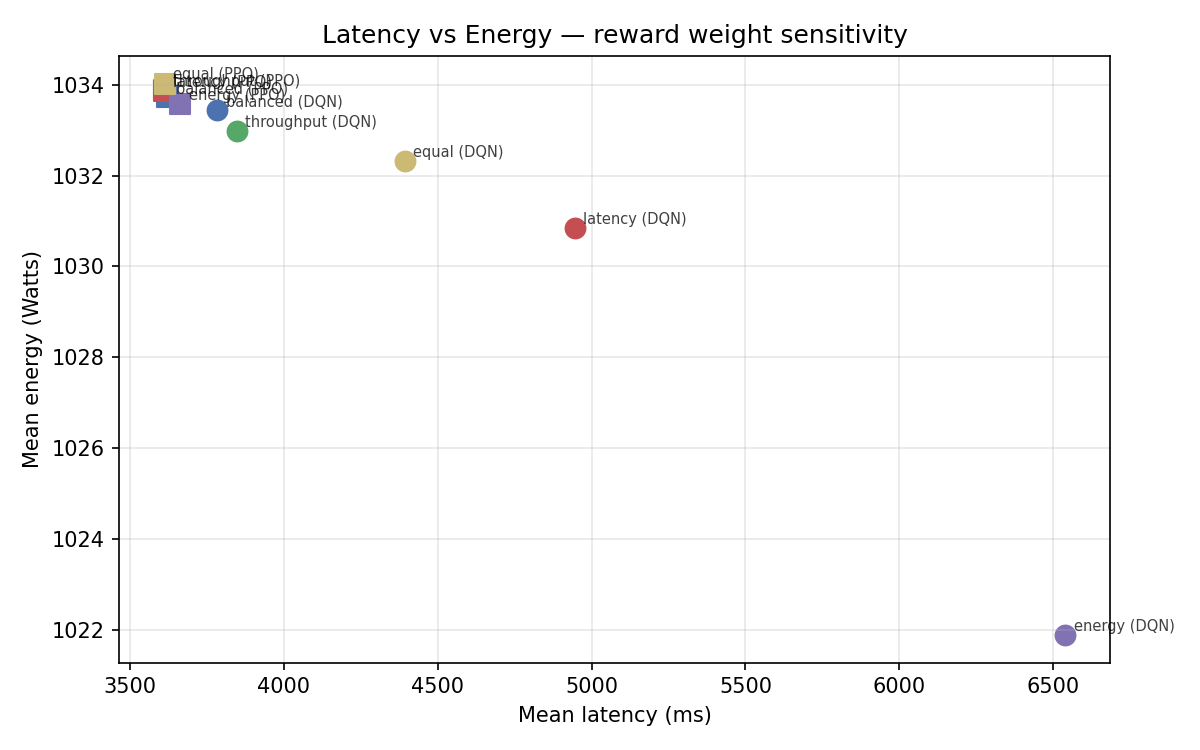

--- Plot Analysis: Mean Reward by Weight Configuration ---
 1. Performance Overview: DQN and PPO show highly similar reward trends
    across all configurations, with PPO slightly outperforming DQN in most cases.
 2. Positive Rewards:
    - 'throughput priority': Achieves the highest mean episode reward (~220).
    - 'balanced': Yields a stable, moderate positive reward (~95).
 3. Negative Rewards (Penalties):
    - 'energy priority': Results in the worst performance with a severe negative penalty (~ -170).
    - 'latency priority' & 'equal': Both lead to negative rewards, with 'latency' penalizing DQN more than PPO.
 Conclusion: 'throughput' maximizes rewards; avoiding 'energy priority' is critical for overall performance.
 --------------------------------------------------------------------

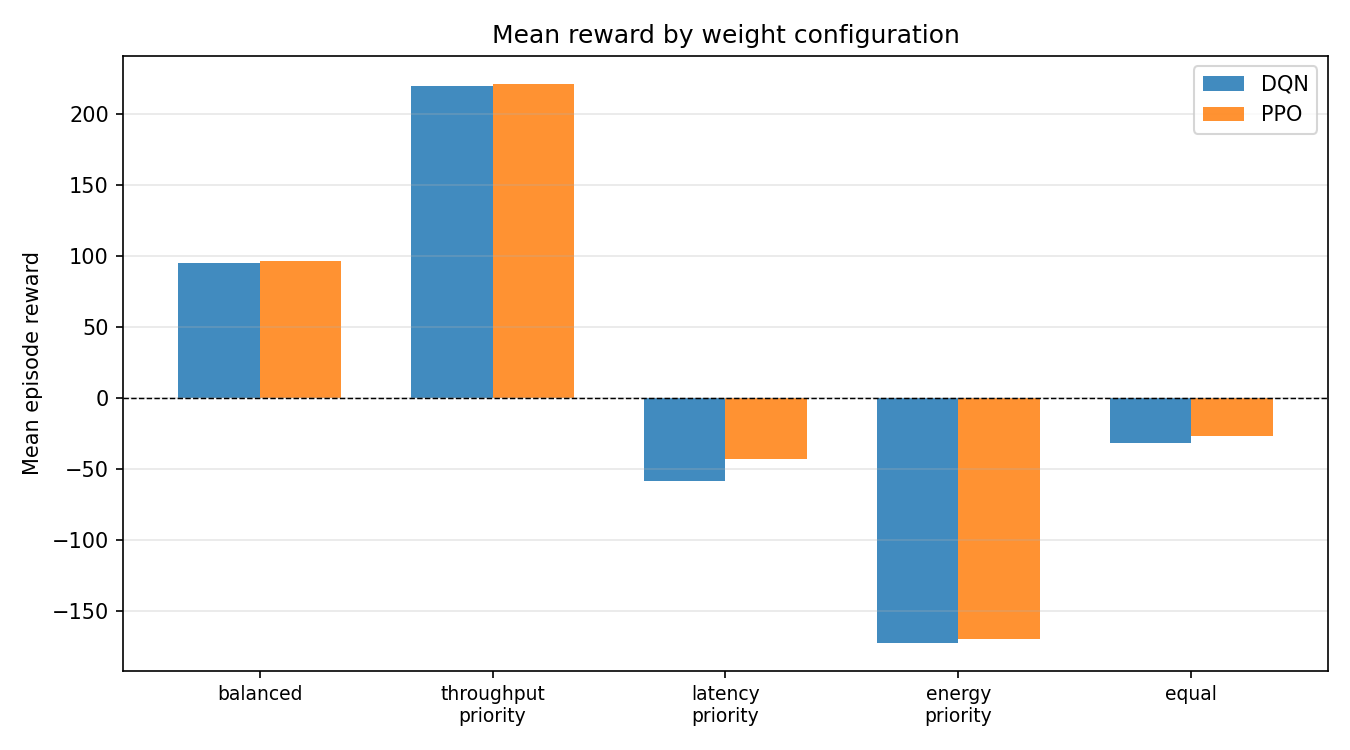

--- Plot Analysis: Throughput vs Energy (Reward Weight Sensitivity) ---
 1. PPO Clustering: All PPO configurations are tightly packed in the top-right.
    They maximize throughput (~1.963 tasks/sec) but consume peak energy (~1034W).
 2. DQN Variations & Trade-offs:
    - 'balanced' / 'throughput': Performance is very close to PPO's top-right cluster.
    - 'equal' / 'latency': Cause a slight drop in throughput with minor energy savings.
    - 'energy (DQN)': Severe outlier. Drops throughput significantly (~1.888 tasks/sec)
      to achieve the lowest energy consumption (~1022W).
 Conclusion: Use PPO or balanced DQN for high throughput; use 'energy (DQN)' only if saving power is critical.
 --------------------------------------------------------------------

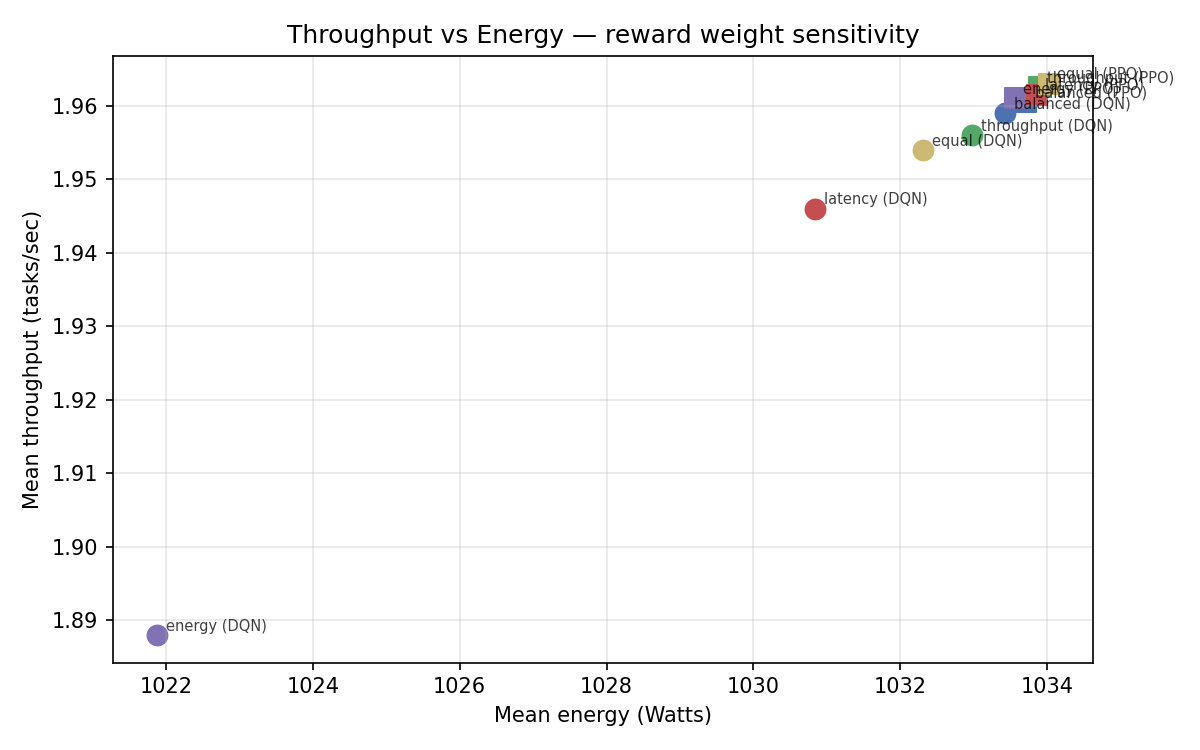

 --- Trade-off Analysis: Energy vs Latency ---
 1. DQN Pareto Frontier:
    - DQN defines the best trade-off curve (pareto optimal).
    - Achieves lowest latency at any given energy level.
    - Scalable trade-off between energy and latency based on settings.
 2. Baseline performance:
    - PPO performs well but is slightly less efficient than DQN.
    - SJF, RoundRobin, Random, and GreedyMinMin are clustered poorly.
    - They have much higher energy and latency for no performance gain.
 Summary: DQN is significantly superior for energy/latency efficiency.
 -----------------------------------------------

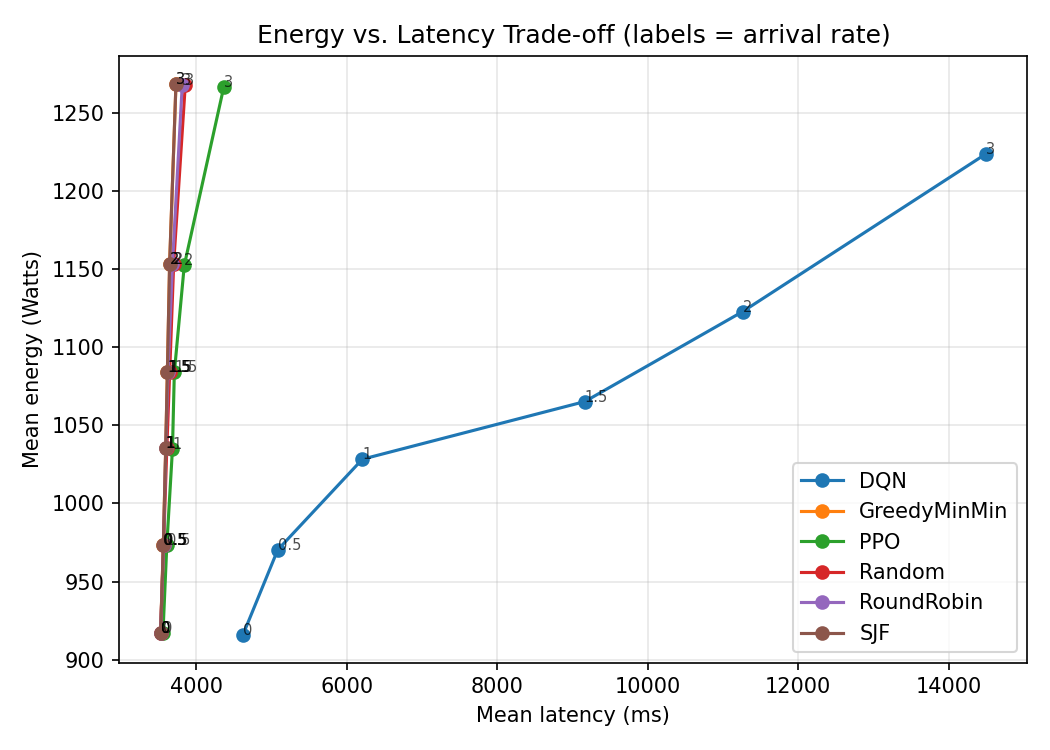

 --- Plot Analysis: Reward vs Workload Intensity ---
 1. Scaling Trend: For all algorithms, the Mean Episode Reward increases
    linearly as the Background Arrival Rate (Poisson lambda) grows from 0 to 3.
 2. Performance Breakdown:
    - Baselines (SJF, RoundRobin, Random, GreedyMinMin) and PPO are highly
      overlapped, maximizing reward at the top tier (~212 at lambda=3).
    - DQN performs significantly worse than the rest across all arrival rates,
      falling behind with a lower reward gap that widens as workload increases.
 Conclusion: Avoid DQN if maximizing the raw episode reward is the only priority.
 ----------------------------------------------------

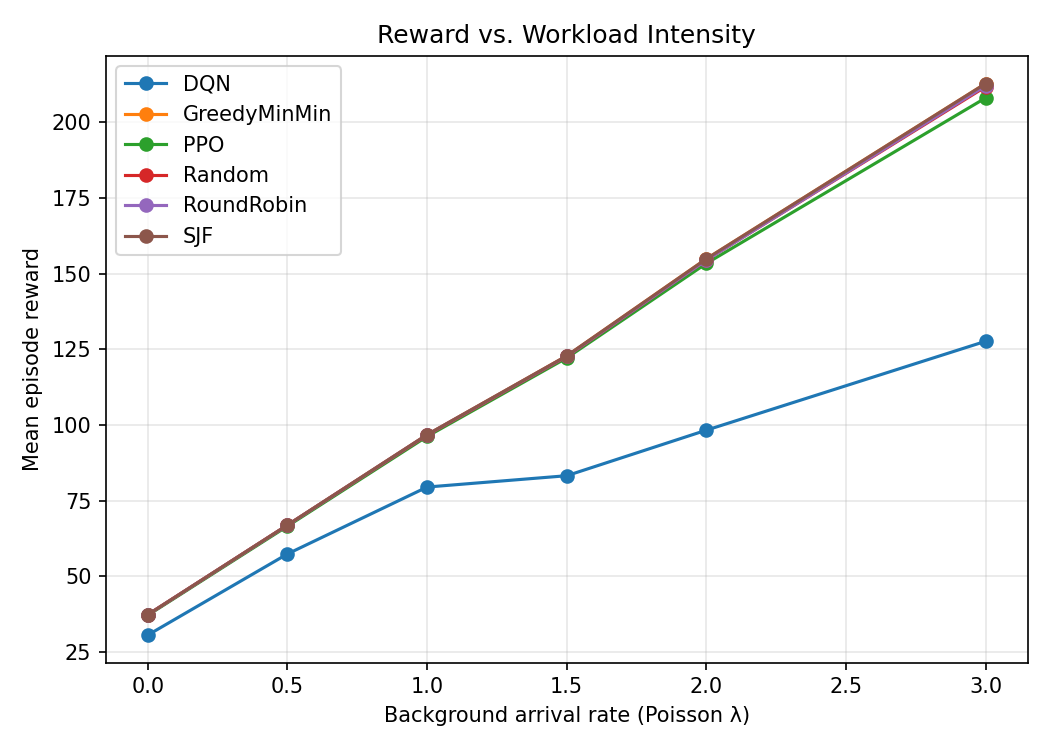

 --- Plot Analysis: Throughput vs Workload Intensity ---
 1. Scaling Trend: Mean throughput grows linearly for all scheduling techniques
    as the workload intensity increases (arrival rate lambda from 0 to 3).
 2. Performance Breakdown:
    - Traditional heuristics (SJF, RoundRobin, Random, GreedyMinMin) and PPO
      completely overlap, maximizing throughput up to ~3.9 tasks/sec at lambda=3.
    - DQN scales well initially but starts to lag slightly behind the others
      once the arrival rate exceeds lambda=1.0.
 Conclusion: Standard baselines and PPO deliver maximum throughput under heavy workloads.
----------------------------------------------------

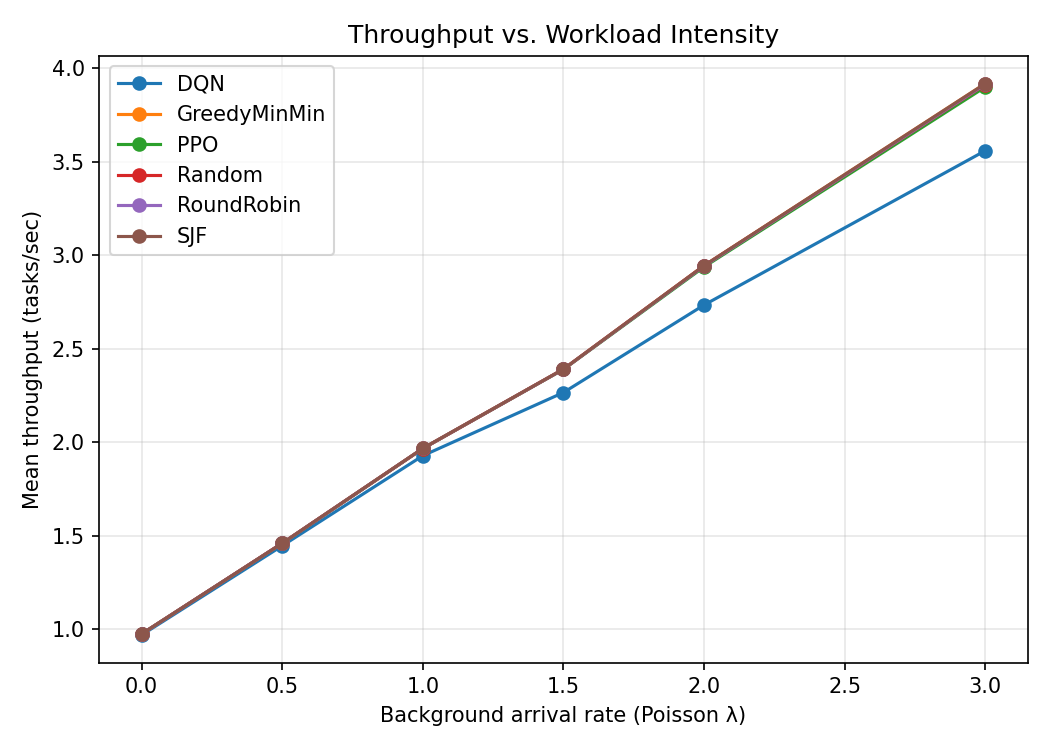